# Example: Building the Cobb-Douglas Allocator

In this example, we pick up the portfolio we built in Session 1 and show how to drive it adaptively. The market is not stationary, and a static portfolio cannot tilt toward the assets that look better as conditions change. 

This example introduces the Cobb-Douglas allocator, a closed-form optimization that turns per-day preference weights into share counts, and asks whether we can react to the market state without abandoning the diversification discipline that the min-var solution gave us.

> __Learning Objectives:__
>
> By the end of this example, you will be able to:
> * __Generate synthetic prices and sentiment:__ Compose a forward simulation by feeding calibrated single-index-model parameters into a generative market surrogate. Derive a scalar sentiment signal from moving-average crossovers and use it to modulate the asset preference weights that drive allocation.
> * __Solve the Cobb-Douglas allocation:__ Solve the budget-constrained Cobb-Douglas allocation problem analytically to obtain optimal share counts. The closed-form solution routes capital toward preferred assets while maintaining a minimum floor for non-preferred ones.
> * __Compare utility function behavior:__ Compare allocation behavior across Cobb-Douglas, CES, and log-linear utility functions under the same preference weights. The choice of utility function controls portfolio concentration even when preferences are held fixed.

Let's dive in!

___

## Setup, Data and Prerequisites
We begin by loading our packages and helper functions via [the `Include.jl` file](./Include.jl). This activates the local [Julia](https://julialang.org) environment and loads all dependencies.

In [1]:
# --- Load packages and helper functions ---
include("Include.jl"); # The Include.jl file activates the local Julia environment and imports all dependencies.

### Constants
In the section below, we set some constants that will be used throughout the notebook. We can modify these constants to explore different scenarios and allocations. 

See the comments in the code for more details on each constant, its purpose, units, etc.

In [2]:
# Allocator configuration
B₀ = 10_000.0               # starting budget (USD)
Δt = 1.0 / 252.0            # trading-day step (years)
L_short = 21                # short EMA window (days)
L_long = 63                 # long EMA window (days)
L_growth = 10               # EMA window for smoothed market growth rate (days)
GAIN = 10.0                 # gain constant G for λ signal (dimensionless)
offset = L_short + L_long   # warmup offset before trading begins (days)
n_trading_days = 252        # trading horizon after warmup (days)
T_total = offset + n_trading_days  # total path length (days)
ε = 0.1                     # minimum share count for non-preferred assets
SCENARIO_SEED = 2026        # RNG seed for the hybrid-SIM scenario generator
CES_ETA_HIGH = 5.0          # high CES elasticity (matches lecture σ_max default)
CES_ETA_LOW  = 0.5          # low CES elasticity (matches lecture σ_min default)
FOCUS_TICKER = "COST"       # ticker used in the single-ticker plots in Task 2 (must be in my_tickers)

"COST"

### Implementation
We define three helper functions used later to measure portfolio concentration across utility functions and to build buy-and-hold baseline wealth series.

> __`top_asset_fraction(shares_mat; ...)`__
>
> Computes the fraction of total portfolio value held in the largest single position at each trading day. Takes a `T×N` share-count matrix `shares_mat` and returns a `Vector{Float64}` of length `T_trade` with values in `[1/N, 1]`.

> __`concentration_stats(shares_mat; ...)`__
>
> Computes the mean and standard deviation of the Herfindahl-Hirschman Index (HHI) across trading days. Takes a `T×N` share-count matrix `shares_mat` and returns a `NamedTuple` with fields `mean::Float64` and `std::Float64`.

> __`buyhold_series(weights, price_matrix, offset, B₀)`__
>
> Computes a buy-and-hold wealth trajectory on a single price path. Buys shares at day `offset+1` using the supplied `weights` and budget `B₀`, then marks to market through the end of the path. Returns a `Vector{Float64}` of length `T - offset`. Used downstream to snapshot the baseline wealth series we hand off to the next notebook.

The three helper definitions appear in the code cell below.

In [3]:
"""
    top_asset_fraction(shares_mat::Matrix{Float64}) -> Vector{Float64}

Compute the fraction of total portfolio value held in the largest single position at each trading day.
Uses the top-level bindings `offset`, `n_trading_days`, `price_matrix`, and `my_tickers`.

### Arguments
- `shares_mat::Matrix{Float64}`: A `T_trade × N` matrix of share counts, where each row is a trading day and each column is an asset.

### Returns
- `Vector{Float64}` of length `T_trade` with values in `[1/N, 1]`.
"""
function top_asset_fraction(shares_mat::Matrix{Float64})::Vector{Float64}

    # --- Step 1: Setup ---
    N = length(my_tickers);
    T_trade = n_trading_days;
    fracs = zeros(T_trade);

    # --- Step 2: Compute top-asset fraction for each trading day ---
    for d in 1:T_trade
        actual_day = offset + d;
        # dollar value of each asset position = shares * price
        values = [shares_mat[d, k] * price_matrix[actual_day, k + 1] for k in 1:N];
        fracs[d] = maximum(values) / sum(values);  # fraction in the largest position
    end

    # --- Step 3: Return ---
    return fracs;
end

"""
    concentration_stats(shares_mat::Matrix{Float64}) -> NamedTuple{(:mean, :std), Tuple{Float64, Float64}}

Compute the mean and standard deviation of the Herfindahl-Hirschman Index (HHI) across trading days.
HHI = sum of squared portfolio weight fractions; ranges from `1/N` (equal weight) to `1.0` (all in one asset).
Uses the top-level bindings `offset`, `n_trading_days`, `price_matrix`, and `my_tickers`.

### Arguments
- `shares_mat::Matrix{Float64}`: A `T_trade × N` matrix of share counts, where each row is a trading day and each column is an asset.

### Returns
- A `NamedTuple` with fields `mean::Float64` and `std::Float64`.
"""
function concentration_stats(shares_mat::Matrix{Float64})

    # --- Step 1: Setup ---
    N = length(my_tickers);
    T_trade = n_trading_days;
    hhi_vals = zeros(T_trade);

    # --- Step 2: Compute HHI for each trading day ---
    for d in 1:T_trade
        actual_day = offset + d;
        # dollar value of each position
        values = [shares_mat[d, k] * price_matrix[actual_day, k + 1] for k in 1:N];
        weights = values ./ sum(values);  # normalize to portfolio weight fractions
        hhi_vals[d] = sum(weights .^ 2);  # HHI = sum of squared weights
    end

    # --- Step 3: Return ---
    return (mean=round(mean(hhi_vals), digits=4), std=round(std(hhi_vals), digits=4));
end

"""
    buyhold_series(weights::Vector{Float64}, price_matrix::Matrix{Float64}, offset::Int, B₀::Float64) -> Vector{Float64}

Compute a buy-and-hold wealth series on a single price path. Shares are purchased at day `offset+1`
using the supplied portfolio weights (summing to one) and an initial budget `B₀`, then held through
the end of the price matrix.

### Arguments
- `weights::Vector{Float64}`: Portfolio weights of length `N`, summing to one.
- `price_matrix::Matrix{Float64}`: `T × (N+1)` price matrix; column 1 is the day index, columns 2:N+1 are ticker prices.
- `offset::Int`: Warmup length in days; the buy-in happens at `offset+1`.
- `B₀::Float64`: Initial budget in dollars.

### Returns
- `Vector{Float64}` of length `T - offset` with the wealth trajectory from the buy-in day forward.
"""
function buyhold_series(weights::Vector{Float64}, price_matrix::Matrix{Float64},
    offset::Int, B₀::Float64)::Vector{Float64}

    # --- Step 1: Setup ---
    T = size(price_matrix, 1);
    N = length(weights);
    t_start = offset + 1;

    # --- Step 2: Shares purchased at buy-in day using weights × B₀ ---
    p_start = [price_matrix[t_start, k + 1] for k in 1:N];
    shares  = B₀ .* weights ./ p_start;

    # --- Step 3: Mark-to-market wealth from buy-in day to end of path ---
    wealth = zeros(T - offset);
    for (i, t) in enumerate(t_start:T)
        wealth[i] = sum(shares[k] * price_matrix[t, k + 1] for k in 1:N);
    end
    return wealth;
end;


To get started, we load the calibrated SIM parameters from Session 1 and generate a single forward path via the generative SIM surrogate. We also return some data about the portfolio we generated in Session 1 that we will use downstream to build the buy-and-hold baseline.

The cell returns:

* `my_tickers::Vector{String}`: ticker universe loaded from the Session 1 calibration.
* `sim_estimates::Vector{MySIMParameterEstimate}`: per-ticker SIM fits (α, β, σ_ε with bootstrap SEs).
* `σ_m::Float64`: market volatility, annualized growth-rate units.
* `g_f::Float64`: continuously compounded risk-free rate.
* `minvar_weights::Vector{Float64}`: Session 1 minimum-variance allocation weights.
* `N::Int`: number of tickers in the universe.
* `sim_params::Dict{String,Tuple{Float64,Float64,Float64}}`: SIM adapter dict (α, β, σ_ε per ticker) for preference-weight computation.

In [4]:
(; my_tickers, sim_estimates, σ_m, g_f, minvar_weights, N, sim_params) = let
    # --- Step 1: Load S1 artifacts (tickers the user picked in Session 1) ---
    minvar = load_results(joinpath(_PATH_TO_DATA_S1, "minvar-allocation.jld2"));
    my_tickers     = minvar["my_tickers"]::Vector{String};
    sim_estimates  = minvar["sim_estimates"];
    σ_m            = Float64(minvar["sigma_market"]);
    g_f            = Float64(minvar["g_f"]);
    minvar_weights = Float64.(minvar["allocation_weights"]);

    # --- Step 2: Rebalancing-engine dimensions ---
    N              = length(my_tickers);

    # --- Step 3: Adapter: build the allocator's sim_params::Dict from sim_estimates ---
    sim_params = Dict{String,Tuple{Float64,Float64,Float64}}(
        e.ticker => (e.α, e.β, e.σ_ε) for e ∈ sim_estimates
    );

    # --- Step 4: Display the universe with SIM parameters (use to pick FOCUS_TICKER) ---
    universe_df = DataFrame(
        "Ticker"     => [e.ticker for e ∈ sim_estimates],
        "α (%/yr)"   => [round(e.α * 100, digits=2) for e ∈ sim_estimates],
        "β"          => [round(e.β, digits=3) for e ∈ sim_estimates],
        "σ_ε (%/yr)" => [round(e.σ_ε * 100, digits=1) for e ∈ sim_estimates],
    );
    println("S1 universe loaded: $(N) tickers (pick one as FOCUS_TICKER)")
    pretty_table(universe_df; backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__compact))
    println("  σ_m (growth rate, 1/yr): $(round(σ_m, digits=4))")
    println("  g_f (continuous, %/yr):  $(round(g_f*100, digits=2))")
    println("Time grid: warmup = $(offset) days, trading = $(n_trading_days) days, total = $(T_total) days")

    # we are returning these values -
    (my_tickers=my_tickers, sim_estimates=sim_estimates, σ_m=σ_m, g_f=g_f,
     minvar_weights=minvar_weights, N=N, sim_params=sim_params)
end;

S1 universe loaded: 20 tickers (pick one as FOCUS_TICKER)
 -------- ---------- --------- ------------
  Ticker   α (%/yr)         β   σ_ε (%/yr) 
  String    Float64   Float64      Float64 
 -------- ---------- --------- ------------
    NFLX      13.23     1.201        637.9
    AMZN       8.77     1.231        369.4
     NKE      -6.43     1.171        385.0
    TSLA      15.47     1.728        716.1
    COST      11.03     0.727        262.7
     SLB     -21.49     1.305        523.6
     JPM       0.06     1.203        263.0
       V       3.99     1.122        207.9
      MA       4.27     1.154       1709.9
     LLY      17.73     0.663        420.9
    ABBV       3.22     0.742        372.7
     CAT       0.09     1.188        278.3
    AAPL      10.47     1.211        355.7
    MSFT      10.03     1.147        234.5
    NVDA      34.75      1.74        488.2
    AVGO      19.25     1.442        417.5
     CRM       2.65     1.293        414.0
    ADBE       5.09     1.245      

___
## Task 1: Generate Synthetic Market Data and Compute Sentiment Signal
In this task, we'll generate one forward market path using the generative market surrogate, then compute per-ticker price paths. From the market factor path, we'll build the short and long exponential moving averages (EMAs) and derive the crossover sentiment signal $\lambda_t$ that will feed into the preference weights.

> __What should we see?__
>
> The market index follows a random trajectory generated by the regime-switching jump model surrogate. The short EMA hugs price; the long EMA smooths it. When the short EMA crosses below the long EMA, $\lambda > 0$ (bearish); when it crosses above, $\lambda < 0$ (bullish). Per-ticker paths are correlated with the market through their $\beta_i$ values and carry the ticker-specific $\alpha_i$ drift and $\sigma_{\epsilon,i}$ idiosyncratic noise.

In the code block below, we load the surrogate models and starting prices, call [the `generate_hybrid_scenario(...)` function](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session3/#eCornellAIFinance.generate_hybrid_scenario) with `n_paths=1, n_steps=T_total, seed=2026`, and compute EMAs, and the sentiment parameter $\lambda$, and the smoothed market growth rate.

The cell returns:

* `market_prices::Vector{Float64}`: synthetic price path of the market index drawn from the generative market surrogate (one Monte Carlo draw, length `T_total`). This is the common factor every ticker is regressed against.
* `price_matrix::Matrix{Float64}`: per-ticker price paths, shape `T_total × N`. Each column is one ticker's path, generated by composing its single-index-model coefficients $(\alpha_i, \beta_i)$ with the market factor and a copula-coupled idiosyncratic residual.
* `ema_short::Vector{Float64}`: short-window exponential moving average of `market_prices` with $L_{\text{short}} = 21$ trading days, tracking near-term momentum.
* `ema_long::Vector{Float64}`: long-window exponential moving average of `market_prices` with $L_{\text{long}} = 63$ trading days, tracking the underlying trend.
* `lambda_series::Vector{Float64}`: EMA-crossover sentiment signal $\lambda_t = -G \cdot (\bar S^{\text{short}}_t / \bar S^{\text{long}}_t - 1)$. Positive in bearish regimes (short EMA below long), negative in bullish regimes; this scalar reshapes the per-asset preference weights $\gamma_i$ in Task 3.
* `gm_ema::Vector{Float64}`: smoothed market log-growth-rate series, computed as the EMA of the per-bar growth $g_{m,t} = \log(S_t / S_{t-1})$ with window $L_{\text{growth}} = 10$. Used as $\mathbb{E}[g_{\mathrm{mkt}}]$ inside the $\gamma_i$ preference map so the allocator reacts to a moving estimate of expected market growth, not the raw noisy daily print.

In [5]:
(; market_prices, price_matrix, ema_short, ema_long, lambda_series, gm_ema) = let
    # --- Step 1: Load surrogates and calibration (source of truth for paths) ---
    market_model = MyMarketSurrogateModel();
    portfolio    = MyPortfolioSurrogateModel();
    calib        = load_results(joinpath(_PATH_TO_DATA_S1, "sim-parameter-estimates.jld2"));

    # --- Step 2: Match S1 start-price snapshot for my_tickers and SPY for the market index ---
    snap = MyCurrentPrices();
    snap_lookup = Dict(snap["tickers"] .=> snap["prices"]);
    start_prices = Dict(t => snap_lookup[t] for t ∈ my_tickers);
    spy_price    = snap_lookup["SPY"];   # seed the synthetic market path at the real SPY close

    # --- Step 3: Generate one hybrid-SIM path over the full T_total horizon ---
    # n_paths = 1 because this notebook illustrates the allocator on a single,
    # reproducible trajectory; distributional analysis lives downstream.
    scenario = generate_hybrid_scenario(market_model, portfolio, calib, my_tickers;
        n_paths      = 1,
        n_steps      = T_total,
        Δt           = Δt,
        start_prices = start_prices,
        P₀_market    = spy_price,
        label        = "S2-CobbDouglas-1p",
        seed         = SCENARIO_SEED);

    # --- Step 4: Extract the single-path market and price series ---
    market_prices = scenario.market_paths[1, :];

    # Build the (T × N+1) price matrix: column 1 = day index, columns 2:N+1 = ticker prices
    price_matrix = zeros(T_total, N + 1);
    price_matrix[:, 1] = 1:T_total;
    for k in 1:N
        price_matrix[:, k + 1] = scenario.price_paths[1, :, k];
    end

    # --- Step 5: EMAs and the λ sentiment signal on the market path ---
    ema_short    = compute_ema(market_prices; window = L_short);
    ema_long     = compute_ema(market_prices; window = L_long);
    lambda_series = compute_lambda(ema_short, ema_long; G = GAIN);
    lambda_series[1:offset] .= 0.0;    # zero warmup period before any EMA signal is usable

    # --- Step 6: Market growth rate (CCGR) and its smoothed version ---
    gm_raw     = compute_market_growth(market_prices; Δt = Δt);
    gm_ema = compute_ema(gm_raw; window = L_growth);

    println("Generated $(T_total) days of synthetic market data via generate_hybrid_scenario")
    println("  SPY start price (USD/share): $(round(spy_price, digits=2))")
    println("  market_prices[end] (USD/share): $(round(market_prices[end], digits=2))")
    println("  λ range: [$(round(minimum(lambda_series), digits=3)), $(round(maximum(lambda_series), digits=3))]")
    (market_prices=market_prices, price_matrix=price_matrix,
     ema_short=ema_short, ema_long=ema_long,
     lambda_series=lambda_series, gm_ema=gm_ema)
end;

Generated 336 days of synthetic market data via generate_hybrid_scenario
  SPY start price (USD/share): 681.92
  market_prices[end] (USD/share): 604.99
  λ range: [-0.378, 0.486]


In the code block below, we plot the market price with both EMAs (top panel) and the lambda sentiment signal (bottom panel).

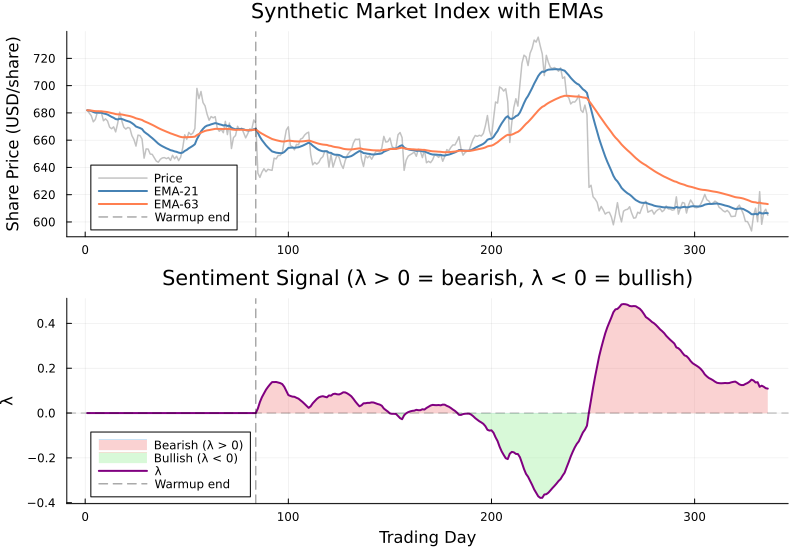

In [6]:
let

    # initialize -
    T_total = length(market_prices);
    days = 1:T_total;

    # --- Top panel: market price with short and long EMAs ---
    p1 = plot(days, market_prices, label="Price", linewidth=1.5, color=:gray70, alpha=0.8)
    plot!(p1, days, ema_short, label="EMA-$(L_short)", linewidth=2, color=:steelblue)
    plot!(p1, days, ema_long, label="EMA-$(L_long)", linewidth=2, color=:coral)
    vline!(p1, [offset], label="Warmup end", linestyle=:dash, color=:black, alpha=0.5)
    ylabel!(p1, "Share Price (USD/share)")
    title!(p1, "Synthetic Market Index with EMAs")

    # --- Bottom panel: lambda sentiment signal with sign-based shading ---
    # Clamp each series to its own half-plane so fillrange=0 shades only that side.
    lam_bear = max.(lambda_series, 0.0);   # bearish part (keeps λ > 0, clamps rest to 0)
    lam_bull = min.(lambda_series, 0.0);   # bullish part (keeps λ < 0, clamps rest to 0)

    p2 = plot(days, lam_bear, fillrange=0, fillalpha=0.35, fillcolor=:lightcoral,
        linewidth=0, label="Bearish (λ > 0)")
    plot!(p2, days, lam_bull, fillrange=0, fillalpha=0.35, fillcolor=:lightgreen,
        linewidth=0, label="Bullish (λ < 0)")
    plot!(p2, days, lambda_series, label="λ", linewidth=2, color=:purple)
    hline!(p2, [0.0], label="", linestyle=:dash, color=:black, alpha=0.3)  # zero reference line
    vline!(p2, [offset], label="Warmup end", linestyle=:dash, color=:black, alpha=0.5)
    xlabel!(p2, "Trading Day")
    ylabel!(p2, "λ")
    title!(p2, "Sentiment Signal (λ > 0 = bearish, λ < 0 = bullish)")

    # --- Combine into 2-row layout ---
    plot(p1, p2, layout=(2, 1), size=(800, 550), legend=:bottomleft)
end

___
## Task 2: Cobb-Douglas Utility Allocation
In this task, we use the Cobb-Douglas utility function to allocate capital. At each time step, we compute preference weights $\gamma_i$ from SIM parameters and the current sentiment $\lambda_t$, then solve the analytical allocation:

$$n_i^{\star} = \underbrace{\left(\frac{\gamma_i}{\sum_{j \in \mathcal{A}^+} \gamma_j}\right)}_{\text{preference share}} \cdot \frac{B_{\text{adj}}}{P_i} \quad \text{for } i \in \mathcal{A}^+, \qquad n_i^{\star} = \epsilon \quad \text{for } i \in \mathcal{A}^-$$
where $B_{\text{adj}} = B - \epsilon \sum_{k \in \mathcal{A}^-} P_k$ is the budget remaining after funding the minimum $\epsilon$ positions in the non-preferred set $\mathcal{A}^-$.  To keep the notation aligned with the Session 2 lecture, we write the asset count as $N$, use the current price shorthand $P_i \equiv S_i(t)$, and interpret the one-step budget as $B \equiv W_{\mathcal{P}}(t)$. The optimal share counts $n_i^{\star}(t)$ map back to portfolio weights through $w_i(t) = n_i(t)S_i(t) / W_{\mathcal{P}}(t)$.

> __What should we see?__
>
> Preference weights shift over time as $\lambda$ changes. During bearish periods ($\lambda > 0$), high-$\beta$ assets should lose preference and the allocator should rotate toward lower-$\beta$ assets. During bullish periods ($\lambda < 0$), the ranking flips. Multiplying the allocation formula through by $P_i$ gives $n_i^{\star} P_i = (\gamma_i / \sum_j \gamma_j)\,B_{\text{adj}}$, so dollars flow to preferred assets in proportion to $\gamma_i$ while share counts scale as $\gamma_i / P_i$. Expensive preferred tickers therefore receive fewer shares than cheap ones at the same preference weight.

In the code block below, we loop over trading days, calling [the `compute_preference_weights(...)` function](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session2/#eCornellAIFinance.compute_preference_weights) to obtain $\gamma_i$ values and then call [the `allocate_cobb_douglas(...)` function](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session2/#eCornellAIFinance.allocate_cobb_douglas) to solve for optimal shares. 

The cell returns `gamma_matrix::Matrix{Float64}` (shape $T_{\text{trade}} \times N$), `shares_matrix::Matrix{Float64}` (shape $T_{\text{trade}} \times N$), and `utility_series::Vector{Float64}` (length $T_{\text{trade}}$).

In [7]:
gamma_matrix, shares_matrix, utility_series = let
    
    # initialize -
    T_trade = n_trading_days; # how many trading days we have after the warmup period (offset)

    # --- Step 1: Allocate storage for time series ---
    gamma_matrix  = zeros(T_trade, N);    # preference weights γᵢ at each trading day
    shares_matrix = zeros(T_trade, N);    # optimal share counts nᵢ* at each trading day
    utility_series = zeros(T_trade);       # Cobb-Douglas utility value at each trading day

    # --- Step 2: Loop over each trading day ---
    for d in 1:T_trade
        actual_day = offset + d;                                         # full-series index (skip warmup)
        λ_t  = lambda_series[actual_day];                                # current sentiment signal
        gm_t = gm_ema[min(actual_day, length(gm_ema))];                  # smoothed market growth
        prices = [price_matrix[actual_day, k + 1] for k in 1:N];         # current prices for all N assets

        # --- Step 2a: Compute preference weights from SIM parameters + sentiment ---
        gamma = compute_preference_weights(sim_params, my_tickers, gm_t, λ_t);

        # --- Step 2b: Build and solve the Cobb-Douglas allocation problem ---
        problem = build(MyCobbDouglasChoiceProblem, (
            gamma = gamma, prices = prices, B = B₀, epsilon = ε
        ));
        (shares, cash) = allocate_cobb_douglas(problem);

        # --- Step 2c: Store results ---
        gamma_matrix[d, :]  = gamma;
        shares_matrix[d, :] = shares;
        utility_series[d]   = evaluate_cobb_douglas(shares, gamma);
    end

    println("Cobb-Douglas allocation computed for $(T_trade) trading days")
    gamma_matrix, shares_matrix, utility_series
end;

Cobb-Douglas allocation computed for 252 trading days


Let's visualize how the optimal allocation changes over time for a single ticker specified by `FOCUS_TICKER` (change that constant to inspect a different ticker). In the code block below, we plot the market sentiment $\lambda$ with bullish/bearish shading (top panel), the preference weight $\gamma$ (middle panel), and the share count $n^{\star}$ (bottom panel), so we can visually correlate sentiment regimes with the allocator's response.

> __What should we see?__
>
> Top panel: $\lambda$ with bearish ($\lambda > 0$) shaded red, bullish ($\lambda < 0$) shaded green. Middle: $\gamma$ tracks $\lambda$, with high-$\beta$ tickers swinging more than low-$\beta$ ones. Bottom: shares scale as $\gamma / P$, so dollar weight is proportional to $\gamma$ but expensive preferred tickers receive fewer shares.
>
> __Caveat: this is the raw allocator, not the deployable strategy.__ The share path will swing day-over-day and drop to the $\varepsilon$-floor whenever $\gamma_i$ crosses zero, because we re-solve the unconstrained Cobb-Douglas optimum on every bar with no turnover cap, schedule, or drawdown gate. The [`RebalancingEngineScorecard`](eCornell-AI-Finance-S2-Example-Core-RebalancingEngineScorecard-May-2026.ipynb) notebook wraps this allocator in the engine's guardrails ($\tau_{\max}$, $b_t$, $d_{\max}$) to produce a path a committee will sign off on. This plot exposes the raw optimizer response, not the production trade tape.

Do we see what we expected?

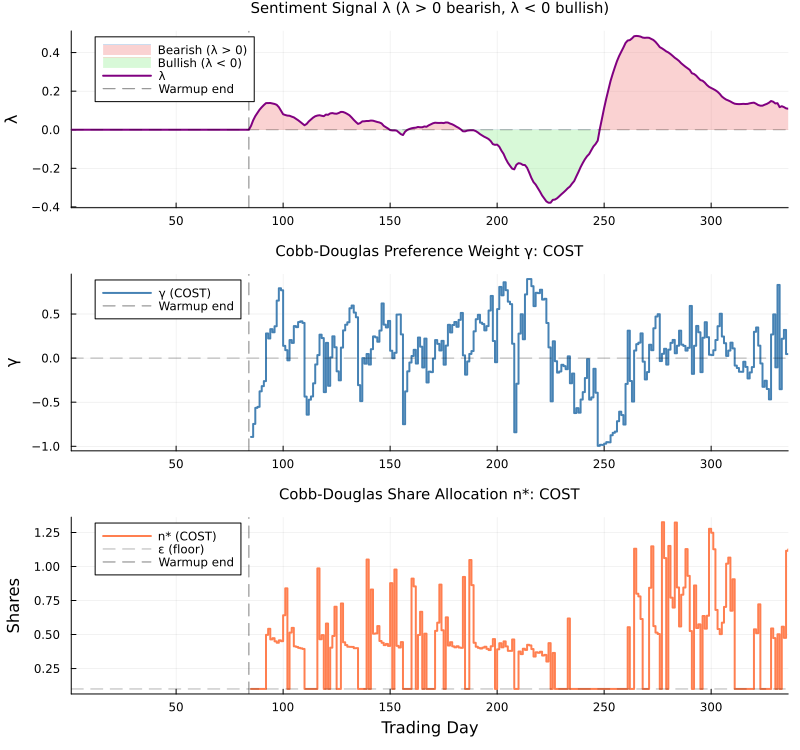

In [8]:
let
    # --- Resolve focus ticker index ---
    k_focus = findfirst(==(FOCUS_TICKER), my_tickers);
    @assert k_focus !== nothing "FOCUS_TICKER = $(FOCUS_TICKER) not found in my_tickers"

    # --- Shared global day indices (all panels span 1:T_total so warmup is visible) ---
    full_days    = 1:T_total;
    trading_days = (offset + 1):(offset + n_trading_days);

    # --- Top panel: λ sentiment signal (full horizon) with sign-based shading ---
    lam_bear = max.(lambda_series, 0.0);   # bearish part (keeps λ > 0, clamps rest to 0)
    lam_bull = min.(lambda_series, 0.0);   # bullish part (keeps λ < 0, clamps rest to 0)
    p1 = plot(full_days, lam_bear, fillrange=0, fillalpha=0.35, fillcolor=:lightcoral,
        linewidth=0, label="Bearish (λ > 0)",
        ylabel="λ", xlim=(1, T_total),
        title="Sentiment Signal λ (λ > 0 bearish, λ < 0 bullish)")
    plot!(p1, full_days, lam_bull, fillrange=0, fillalpha=0.35, fillcolor=:lightgreen,
        linewidth=0, label="Bullish (λ < 0)")
    plot!(p1, full_days, lambda_series, label="λ", linewidth=2, color=:purple)
    hline!(p1, [0.0], label="", linestyle=:dash, color=:black, alpha=0.3)
    vline!(p1, [offset], label="Warmup end", linestyle=:dash, color=:black, alpha=0.5)

    # --- Middle panel: γ (stairstep) for the focus ticker, plotted on global day axis ---
    p2 = plot(trading_days, gamma_matrix[:, k_focus],
        linetype=:steppost,
        linewidth=2, color=:steelblue, label="γ ($(FOCUS_TICKER))",
        ylabel="γ", xlim=(1, T_total),
        title="Cobb-Douglas Preference Weight γ: $(FOCUS_TICKER)")
    hline!(p2, [0.0], label="", linestyle=:dash, color=:black, alpha=0.3)
    vline!(p2, [offset], label="Warmup end", linestyle=:dash, color=:black, alpha=0.5)

    # --- Bottom panel: n* (stairstep) for the focus ticker, plotted on global day axis ---
    p3 = plot(trading_days, shares_matrix[:, k_focus],
        linetype=:steppost,
        linewidth=2, color=:coral, label="n* ($(FOCUS_TICKER))",
        xlabel="Trading Day", ylabel="Shares", xlim=(1, T_total),
        title="Cobb-Douglas Share Allocation n*: $(FOCUS_TICKER)")
    hline!(p3, [ε], label="ε (floor)", linestyle=:dash, color=:black, alpha=0.3)
    vline!(p3, [offset], label="Warmup end", linestyle=:dash, color=:black, alpha=0.5)

    # --- Combine into 3-row layout ---
    plot(p1, p2, p3, layout=(3, 1), size=(800, 750), legend=:topleft, titlefontsize=10)
end

__Why do preferred tickers sometimes drop to the floor during _bullish_ stretches?__

The preference formula $\gamma_i = \tanh(\alpha_i/\beta_i^{\lambda} + \beta_i^{1-\lambda}\,g_m)$ uses two market signals: $\lambda$ (EMA crossover, slow) and $g_m$ (smoothed market growth, fast). When the market peaks and starts falling, $g_m$ flips negative before $\lambda$ confirms a reversal, because the EMA crossover lags price. The dominant term $\beta^{1-\lambda}\,g_m$ then carries a **negative** $g_m$ while $\lambda$ still says _bullish_, and $\gamma$ can flip below zero, sending the ticker to the $\epsilon$ floor.

So the rule isn't _bullish means high-$\beta$ wins_. It's $g_m$ decides who wins, $\lambda$ controls how much. When $\lambda$ and $g_m$ disagree, $g_m$ wins, and the allocator correctly reads _market falling_ from $g_m$ even before the crossover signal catches up. This is a feature: $\lambda$ gives us the trend frame, $g_m$ gives us the freshness.

___
## Task 3: Compare Utility Functions (Cobb-Douglas vs. CES vs. Log-Linear)
In this task, we run the same scenario with three different utility functions and compare allocation behavior. The key question: **how does the choice of utility function affect portfolio concentration?**

CES with high $\eta$ (elasticity of substitution) produces more concentrated portfolios, pushing more budget toward the single best asset. Cobb-Douglas is the middle ground. Log-linear produces the same allocation as Cobb-Douglas but different utility values.

> __What should we see?__
>
> Cobb-Douglas and log-linear allocations will be identical (the log transform preserves the optimum). CES with $\eta = $ `CES_ETA_HIGH` will be more concentrated, with the top asset getting a larger share of the budget. CES with $\eta = $ `CES_ETA_LOW` will be more diversified.

In the code block below, we compute allocations for all four utility variants using [the `allocate_cobb_douglas(...)` function](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session2/#eCornellAIFinance.allocate_cobb_douglas), [the `allocate_ces(...)` function](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session2/#eCornellAIFinance.allocate_ces), and [the `allocate_log_linear(...)` function](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session2/#eCornellAIFinance.allocate_log_linear). 

The cell returns eight arrays: four share-count matrices (each of shape $T_{\text{trade}} \times N$, with row $d$ a trading day after warmup and column $k$ an asset in `my_tickers` order) and four utility series (each of length $T_{\text{trade}}$):

* `shares_cd::Matrix{Float64}`: Cobb-Douglas optimal share counts $n_i^{\star}$ per trading day.
* `shares_ces_high::Matrix{Float64}`: CES share counts at high elasticity $\eta = $ `CES_ETA_HIGH` (concentrated regime: the top preferred asset absorbs most of the budget).
* `shares_ces_low::Matrix{Float64}`: CES share counts at low elasticity $\eta = $ `CES_ETA_LOW` (diversified regime: budget spreads across the preferred set).
* `shares_ll::Matrix{Float64}`: Log-linear share counts; identical to `shares_cd` row-for-row because the log transform preserves the Cobb-Douglas optimum.
* `utility_cd::Vector{Float64}`: Cobb-Douglas utility value $U = \kappa \prod_i n_i^{\gamma_i}$ per day. Magnitudes span many orders; the sign flag $\kappa = -1$ whenever any $\gamma_i < 0$.
* `utility_ces_high::Vector{Float64}`: CES utility value $U = \left(\sum_i \gamma_i\,n_i^{\rho}\right)^{1/\rho}$ per day at $\eta = $ `CES_ETA_HIGH`, where $\rho = (\eta - 1)/\eta$.
* `utility_ces_low::Vector{Float64}`: Same as above but at $\eta = $ `CES_ETA_LOW`.
* `utility_ll::Vector{Float64}`: Log-linear utility value $\sum_{i \in \mathcal{A}^+} \gamma_i \ln n_i$ per day. Numerically well-behaved and preserves the Cobb-Douglas ordering on the preferred set.

In [9]:
(; shares_cd, shares_ces_high, shares_ces_low, shares_ll,
   utility_cd, utility_ces_high, utility_ces_low, utility_ll) = let
    
    # --- Setup ---
    T_trade = n_trading_days; # how many trading days we have after the warmup period (offset)

    # --- Step 1: Allocate storage for each utility variant ---
    shares_cd       = zeros(T_trade, N);   # Cobb-Douglas shares
    shares_ces_high = zeros(T_trade, N);   # CES σ = 3.0 (concentrated)
    shares_ces_low  = zeros(T_trade, N);   # CES σ = 0.5 (diversified)
    shares_ll       = zeros(T_trade, N);   # Log-linear shares

    utility_cd       = zeros(T_trade);     # Cobb-Douglas utility values
    utility_ces_high = zeros(T_trade);     # CES high-σ utility values
    utility_ces_low  = zeros(T_trade);     # CES low-σ utility values
    utility_ll       = zeros(T_trade);     # Log-linear utility values

    # --- Step 2: Loop over trading days and compute all allocations ---
    for d in 1:T_trade
        actual_day = offset + d;  # skip warmup
        λ_t  = lambda_series[actual_day];
        gm_t = gm_ema[min(actual_day, length(gm_ema))];
        prices = [price_matrix[actual_day, k + 1] for k in 1:N];

        # preference weights are the same for all utility functions
        gamma = compute_preference_weights(sim_params, my_tickers, gm_t, λ_t);

        # --- Cobb-Douglas allocation ---
        cd_prob = build(MyCobbDouglasChoiceProblem, (gamma=gamma, prices=prices, B=B₀, epsilon=ε));
        (s_cd, _) = allocate_cobb_douglas(cd_prob);
        shares_cd[d, :] = s_cd;
        utility_cd[d]   = evaluate_cobb_douglas(s_cd, gamma);

        # --- CES high σ (concentrated, σ = 3.0) ---
        ces_h = build(MyCESChoiceProblem, (gamma=gamma, prices=prices, B=B₀, epsilon=ε, eta=CES_ETA_HIGH));
        (s_ces_h, _) = allocate_ces(ces_h);
        shares_ces_high[d, :] = s_ces_h;
        utility_ces_high[d]   = evaluate_ces(s_ces_h, gamma; eta=CES_ETA_HIGH);

        # --- CES low σ (diversified, σ = 0.5) ---
        ces_l = build(MyCESChoiceProblem, (gamma=gamma, prices=prices, B=B₀, epsilon=ε, eta=CES_ETA_LOW));
        (s_ces_l, _) = allocate_ces(ces_l);
        shares_ces_low[d, :] = s_ces_l;
        utility_ces_low[d]   = evaluate_ces(s_ces_l, gamma; eta=CES_ETA_LOW);

        # --- Log-linear allocation ---
        ll_prob = build(MyLogLinearChoiceProblem, (gamma=gamma, prices=prices, B=B₀, epsilon=ε));
        (s_ll, _) = allocate_log_linear(ll_prob);
        shares_ll[d, :] = s_ll;
        utility_ll[d]   = evaluate_log_linear(s_ll, gamma);
    end

    println("Allocation computed for all 4 utility variants")
    (shares_cd=shares_cd, shares_ces_high=shares_ces_high, shares_ces_low=shares_ces_low, shares_ll=shares_ll,
     utility_cd=utility_cd, utility_ces_high=utility_ces_high, utility_ces_low=utility_ces_low, utility_ll=utility_ll)
end;

Allocation computed for all 4 utility variants


Let's compare how each utility function allocates capital to the single ticker `FOCUS_TICKER` under the same sentiment signal. In the code block below, we stack four panels: the market sentiment $\lambda$ (top), and the share count $n^{\star}$ for `FOCUS_TICKER` under Cobb-Douglas, CES (both elasticities overlaid), and log-linear.

> __What should we see?__
>
> The Cobb-Douglas and log-linear panels should be identical; the log transform preserves the optimum. The CES panel shows both elasticities on the same axis: high $\eta$ (concentrated) should produce larger share counts when the ticker is preferred and more floor periods when it's not, while low $\eta$ (diversified) smooths the allocation with smaller swings and fewer floor periods. 
> 
> Comparing against the sentiment panel shows how utility choice controls how aggressively the allocator responds to the same $\gamma$ preference signal. As in Task 2, these are still raw per-bar optima with no turnover cap, schedule, or drawdown gate; the [`RebalancingEngineScorecard`](eCornell-AI-Finance-S2-Example-Core-RebalancingEngineScorecard-May-2026.ipynb) notebook is what enforces deployable rebalance discipline.

So what do we see?

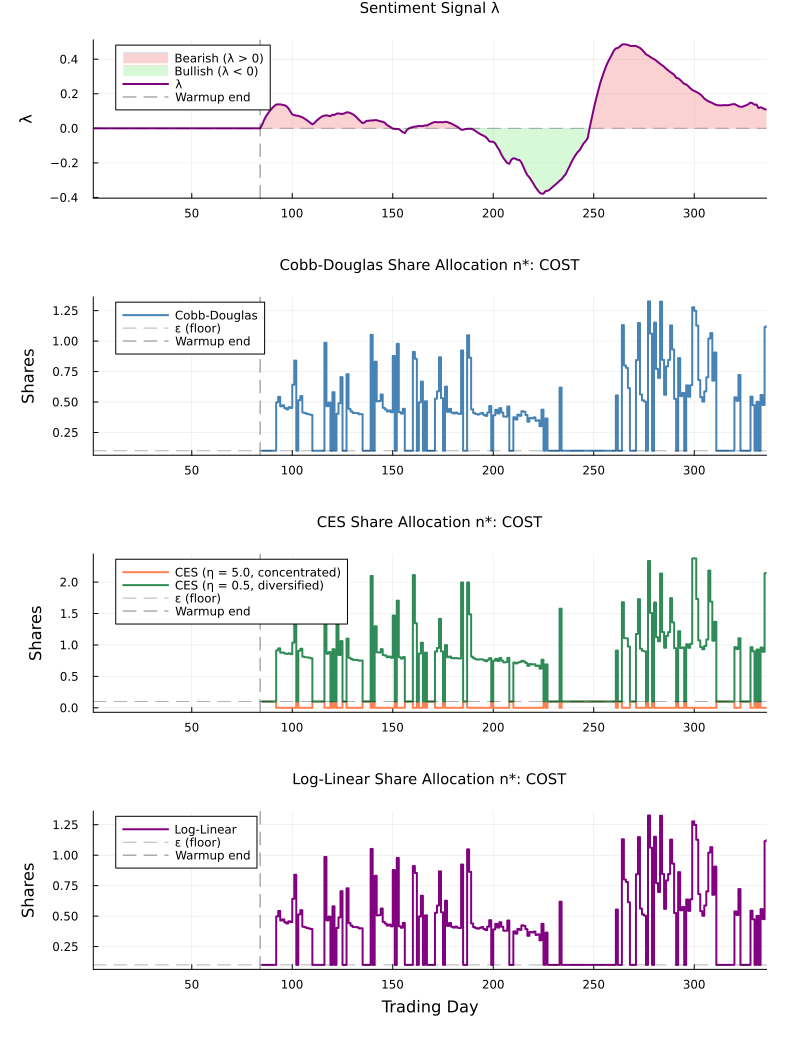

In [10]:
let
    # --- Resolve focus ticker index ---
    k_focus = findfirst(==(FOCUS_TICKER), my_tickers);
    @assert k_focus !== nothing "FOCUS_TICKER = $(FOCUS_TICKER) not found in my_tickers"

    # --- Shared global day indices (all panels span 1:T_total so warmup is visible) ---
    full_days    = 1:T_total;
    trading_days = (offset + 1):(offset + n_trading_days);

    # --- Panel 1: λ sentiment signal (full horizon) with sign-based shading ---
    lam_bear = max.(lambda_series, 0.0);   # bearish part (keeps λ > 0, clamps rest to 0)
    lam_bull = min.(lambda_series, 0.0);   # bullish part (keeps λ < 0, clamps rest to 0)
    p1 = plot(full_days, lam_bear, fillrange=0, fillalpha=0.35, fillcolor=:lightcoral,
        linewidth=0, label="Bearish (λ > 0)",
        ylabel="λ", xlim=(1, T_total),
        title="Sentiment Signal λ")
    plot!(p1, full_days, lam_bull, fillrange=0, fillalpha=0.35, fillcolor=:lightgreen,
        linewidth=0, label="Bullish (λ < 0)")
    plot!(p1, full_days, lambda_series, label="λ", linewidth=2, color=:purple)
    hline!(p1, [0.0], label="", linestyle=:dash, color=:black, alpha=0.3)
    vline!(p1, [offset], label="Warmup end", linestyle=:dash, color=:black, alpha=0.5)

    # --- Panel 2: Cobb-Douglas share count (stairstep) ---
    p2 = plot(trading_days, shares_cd[:, k_focus],
        linetype=:steppost,
        linewidth=2, color=:steelblue, label="Cobb-Douglas",
        ylabel="Shares", xlim=(1, T_total),
        title="Cobb-Douglas Share Allocation n*: $(FOCUS_TICKER)")
    hline!(p2, [ε], label="ε (floor)", linestyle=:dash, color=:black, alpha=0.3)
    vline!(p2, [offset], label="Warmup end", linestyle=:dash, color=:black, alpha=0.5)

    # --- Panel 3: CES share counts (both η overlaid, stairstep) ---
    p3 = plot(trading_days, shares_ces_high[:, k_focus],
        linetype=:steppost,
        linewidth=2, color=:coral, label="CES (η = $(CES_ETA_HIGH), concentrated)",
        ylabel="Shares", xlim=(1, T_total),
        title="CES Share Allocation n*: $(FOCUS_TICKER)")
    plot!(p3, trading_days, shares_ces_low[:, k_focus],
        linetype=:steppost,
        linewidth=2, color=:seagreen, label="CES (η = $(CES_ETA_LOW), diversified)")
    hline!(p3, [ε], label="ε (floor)", linestyle=:dash, color=:black, alpha=0.3)
    vline!(p3, [offset], label="Warmup end", linestyle=:dash, color=:black, alpha=0.5)

    # --- Panel 4: Log-linear share count (stairstep) ---
    p4 = plot(trading_days, shares_ll[:, k_focus],
        linetype=:steppost,
        linewidth=2, color=:purple, label="Log-Linear",
        xlabel="Trading Day", ylabel="Shares", xlim=(1, T_total),
        title="Log-Linear Share Allocation n*: $(FOCUS_TICKER)")
    hline!(p4, [ε], label="ε (floor)", linestyle=:dash, color=:black, alpha=0.3)
    vline!(p4, [offset], label="Warmup end", linestyle=:dash, color=:black, alpha=0.5)

    # --- Combine into 4-row layout ---
    plot(p1, p2, p3, p4, layout=(4, 1), size=(800, 1050),
        legend=:topleft, titlefontsize=10,
        left_margin=8Plots.mm, right_margin=6Plots.mm,
        top_margin=3Plots.mm, bottom_margin=6Plots.mm)
end

In the code block below, we compute summary statistics (mean and standard deviation of the Herfindahl-Hirschman Index) for each utility function and displays them using [`pretty_table`](https://ronisbr.github.io/PrettyTables.jl/stable/).

> __What is the Herfindahl-Hirschman Index (HHI)?__
>
> The HHI is a single-number measure of portfolio concentration, defined as the sum of squared portfolio weights (dollar fractions) across assets. For a portfolio with $N$ assets, where each asset $i$ has weight $w_i(t)$ at time $t$, the HHI is given by:
>
> $$\text{HHI}(t) = \sum_{i=1}^{N} w_i(t)^{2}, \qquad w_i(t) = \frac{n_i(t)\,P_i(t)}{\sum_{j=1}^{N} n_j(t)\,P_j(t)}.$$
>
> where $P_i(t)$ is the price of asset $i$ at time $t$, and $n_i(t)$ is the number of shares of asset $i$ held at time $t$. The HHI ranges from $1/N$ (equal weight across all $N$ assets: maximally diversified) to $1.0$ (all budget in a single asset: maximally concentrated). The mean over trading days reports the allocator's typical concentration; the standard deviation reports how much that concentration moves as sentiment shifts. 

Let's take a look at how the HHI concentration statistics compare across utility functions. Do we see what we expected? 

In [11]:
let
    # --- Step 1: Compute HHI for each utility variant ---
    names = ["Cobb-Douglas", "CES (σ=3.0)", "CES (σ=0.5)", "Log-Linear"];
    mats  = [shares_cd, shares_ces_high, shares_ces_low, shares_ll];
    stats = [concentration_stats(m) for m ∈ mats];

    # --- Step 2: Build the summary DataFrame ---
    floor_val = round(1.0 / N, digits=4);    # equal-weight HHI floor = 1/N
    df = DataFrame(
        "Utility Function" => names,
        "Mean HHI"         => [s.mean for s ∈ stats],
        "Std HHI"          => [s.std  for s ∈ stats],
        "1/N (floor)"      => fill(floor_val, length(names)),
        "Mean / Floor"     => [round(s.mean / floor_val, digits=2) for s ∈ stats],
    );

    # --- Step 3: Display ---
    pretty_table(df; backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__compact))
end

 ------------------ ---------- --------- ------------- --------------
  Utility Function   Mean HHI   Std HHI   1/N (floor)   Mean / Floor 
            String    Float64   Float64       Float64        Float64 
 ------------------ ---------- --------- ------------- --------------
      Cobb-Douglas     0.1405    0.1986          0.05           2.81
       CES (σ=3.0)     0.4549    0.2846          0.05            9.1
       CES (σ=0.5)     0.1396    0.1982          0.05           2.79
        Log-Linear     0.1405    0.1986          0.05           2.81
 ------------------ ---------- --------- ------------- --------------


___
### Hand-off to the next notebook
We now construct the rebalancing engine context and save the artifacts the next notebook will consume. 

In the code block below, we build a [`MyRebalancingContextModel`](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session2/#eCornellAIFinance.MyRebalancingContextModel) from the single-path price data, precompute three baseline wealth series (S1 min-var buy-and-hold, equal-weight buy-and-hold, and the deterministic risk-free curve at rate `g_f`), and write `engine-run-data.jld2` to the Session 2 data directory. 

The downstream `RebalancingEngineScorecard` notebook loads this file verbatim.

In [12]:
let
    # --- Step 1: Build the rebalancing engine context from the single-path data ---
    context = build(MyRebalancingContextModel, (
        B              = B₀,
        tickers        = my_tickers,
        marketdata     = price_matrix,
        marketfactor   = gm_ema,
        sim_parameters = sim_params,
        lambda         = 0.0,        # placeholder; the engine pulls λ_t from lambda_series
        Δt             = Δt,
        epsilon        = ε,
    ));

    # --- Step 2: Three baseline wealth series on this single path ---
    eqw = fill(1.0 / N, N);
    minvar_wealth      = buyhold_series(minvar_weights, price_matrix, offset, B₀);
    equalweight_wealth = buyhold_series(eqw,            price_matrix, offset, B₀);
    riskfree_wealth    = [B₀ * exp(g_f * (t - 1) * Δt) for t ∈ 1:n_trading_days];

    # --- Step 3: Save everything the next notebook needs ---
    save_path = joinpath(_PATH_TO_DATA, "engine-run-data.jld2");
    save_results(save_path, Dict(
        "my_tickers"         => my_tickers,
        "price_matrix"       => price_matrix,
        "market_prices"      => market_prices,
        "lambda_series"      => lambda_series,
        "gm_ema"             => gm_ema,
        "sim_params"         => sim_params,
        "context"            => context,
        "minvar_wealth"      => minvar_wealth,
        "equalweight_wealth" => equalweight_wealth,
        "riskfree_wealth"    => riskfree_wealth,
        "minvar_weights"     => minvar_weights,
        "g_f"                => g_f,
        "B₀"                 => B₀,
    ));

    println("Saved engine run data to: $(save_path)")
    println("  $(N) tickers, $(T_total) total days ($(offset) warmup + $(n_trading_days) trading)")
    println("  Baselines (final W / W₀): ",
        "minvar=", round(minvar_wealth[end] / B₀, digits=3),
        ", eq-wt=", round(equalweight_wealth[end] / B₀, digits=3),
        ", rf=",    round(riskfree_wealth[end]  / B₀, digits=3))
end

Saved engine run data to: /Users/jdv27/Desktop/julia_work/eCornell-AI-finance-lectures/lectures/session-2/data/engine-run-data.jld2
  20 tickers, 336 total days (84 warmup + 252 trading)
  Baselines (final W / W₀): minvar=1.126, eq-wt=1.0, rf=1.046


___
## Summary
The Cobb-Douglas allocator translates SIM-based preference weights and EMA crossover sentiment into budget-constrained share allocations that adapt as market conditions change. In this example we loaded the user-selected universe and calibrated SIM parameters from Session 1, generated one generative SIM forward path, solved the Cobb-Douglas allocation on each trading day, compared Cobb-Douglas against CES and log-linear alternatives, and wrote the single-path data to `engine-run-data.jld2` for the next notebook.

> __Key Takeaways:__
>
> * __Cobb-Douglas and log-linear produce identical allocations:__ The log transform preserves the optimum, so the choice between them only matters when utility values are used as reward signals. Both yield the same share counts for the same preference weights.
> * __CES elasticity controls concentration:__ High elasticity of substitution concentrates the portfolio toward the top asset, while low elasticity diversifies across all assets. This provides a single parameter to tune conviction versus robustness.
> * __Preference weights bridge fundamentals and sentiment:__ The preference weights combine the Session 1 SIM parameters with the EMA crossover signal, so the allocator adapts as market conditions change without manual reweighting. This closes the feedback loop that was missing in the static Session 1 portfolio.

### Disclaimer
This content is for educational purposes only and does not constitute investment advice. The examples use synthetic data and simplified models.

___